The codes prepared by the teacher were in MATLAB. I have converted or better to say translated them to simple python codes because I like python more :)

In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
dpt = np.arange(0, 3.001, 0.001) # Depth values 
npt = len(dpt)
temp_grad = 35 # in degree centigrade
temp0 = 25

# Variation of temperature with depth
T = temp0 + temp_grad * dpt

How does conductivity vary with depth?

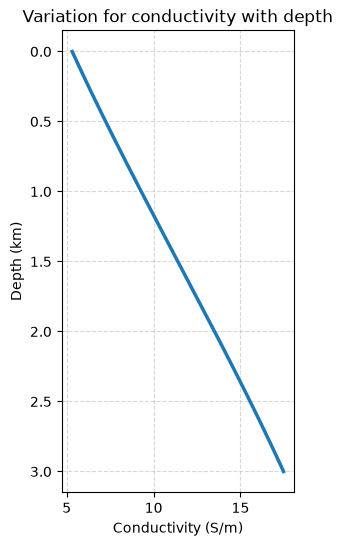

In [23]:
sigma = 2.903916 * (1 + 0.0297175 * T + 1.5551 * (10**(-4)) * T**2 - 6.7 * (10**(-7)) * T**3)

plt.figure(figsize=(3,6))
plt.plot(sigma, dpt, lw = 2.5)
plt.xlabel("Conductivity (S/m)")
plt.ylabel("Depth (km)")
plt.title("Variation for conductivity with depth")
plt.gca().invert_yaxis()
plt.grid("True", alpha = 0.5, ls = "--")
plt.show()

Athy's equation for porosity

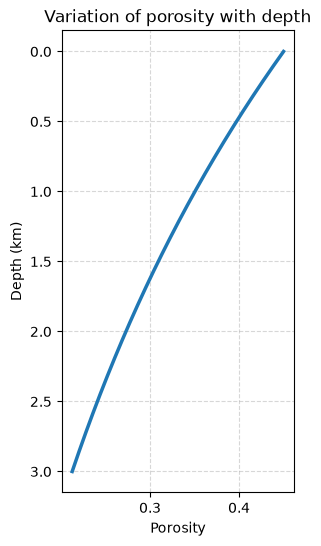

In [24]:
phi0 = 0.45 # 0.45 - 0.50 for sandstone; 0.60 - 0.80 for shale
k = 0.25 # 0.20 - 0.35 for sandstone; 0.45 - 0.70 for shale 

phi = phi0 * np.exp(-k * dpt)
phi_mud = 0.7 * np.exp(-0.55 * dpt)
phi_sand = 0.45 * np.exp(-0.25 * dpt)

plt.figure(figsize=(3,6))
plt.plot(phi, dpt, lw = 2.5)
plt.xlabel("Porosity")
plt.ylabel("Depth (km)")
plt.gca().invert_yaxis()
plt.grid("True", alpha = 0.5, ls = "--")
plt.title("Variation of porosity with depth")
plt.show()

Archie's equation

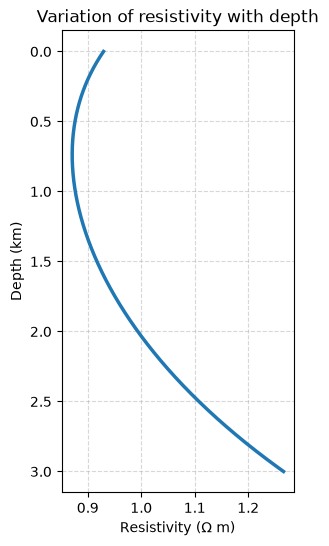

In [29]:
a = 1
m = 2
n = 2
Sw = np.ones(npt)

bulk_resistivity = a / ((phi**m) * (Sw**n) * sigma)

plt.figure(figsize=(3,6))
plt.plot(bulk_resistivity, dpt, lw = 2.5)
plt.xlabel(r"Resistivity ($\Omega$ m)")
plt.ylabel("Depth (km)")
plt.gca().invert_yaxis()
plt.grid("True", alpha = 0.5, ls = "--")
plt.title("Variation of resistivity with depth")
plt.show()

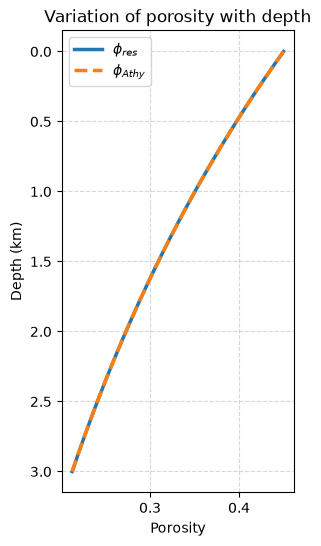

In [32]:
phi_est = (a / (bulk_resistivity * (Sw**n) * sigma)) ** (1/m) # depth varying temperature (actual temperature case)
phi_est_cT = (a / (bulk_resistivity * (Sw**n) * 2.903916)) ** (1/m) # constant temperature case

plt.figure(figsize=(3,6))
plt.plot(phi_est, dpt, lw = 2.5, label=r"$\phi_{res}$")
plt.plot(phi_sand, dpt, ls = "--", lw = 2.5, label=r"$\phi_{Athy}$")
plt.xlabel("Porosity")
plt.ylabel("Depth (km)")
plt.gca().invert_yaxis()
plt.grid("True", alpha = 0.5, ls = "--")
plt.title("Variation of porosity with depth")
plt.legend()
plt.show()

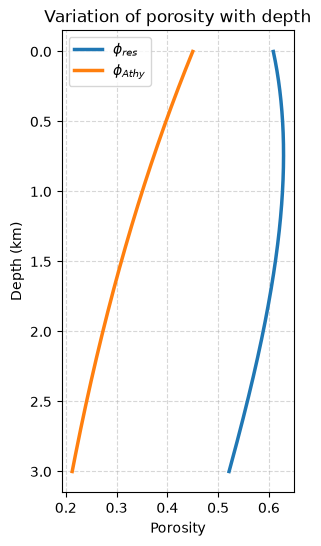

In [ ]:
plt.figure(figsize=(3,6))
plt.plot(phi_est_cT, dpt, lw = 2.5, label=r"$\phi_{res}$ at constant temp")
plt.plot(phi_sand, dpt, lw = 2.5, label=r"$\phi_{Athy}$")
plt.xlabel("Porosity")
plt.ylabel("Depth (km)")
plt.gca().invert_yaxis()
plt.grid("True", alpha = 0.5, ls = "--")
plt.title("Variation of porosity with depth")
plt.legend()
plt.show()

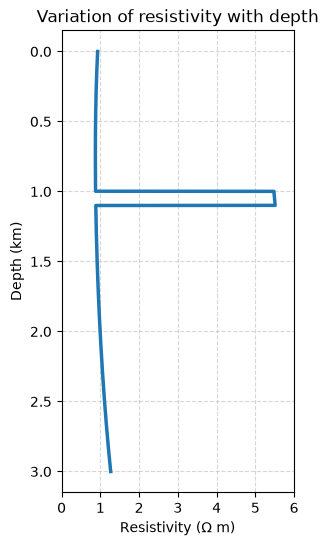

In [40]:
a = 1
m = 2
n = 2
Sw = np.ones(npt)
Sw[999:1100] = 0.4

bulk_resistivity = a / ((phi**m) * (Sw**n) * sigma)

plt.figure(figsize=(3,6))
plt.plot(bulk_resistivity, dpt, lw = 2.5)
plt.xlabel(r"Resistivity ($\Omega$ m)")
plt.ylabel("Depth (km)")
plt.xticks(np.arange(0,7))
plt.gca().invert_yaxis()
plt.grid("True", alpha = 0.5, ls = "--")
plt.title("Variation of resistivity with depth")
plt.show()

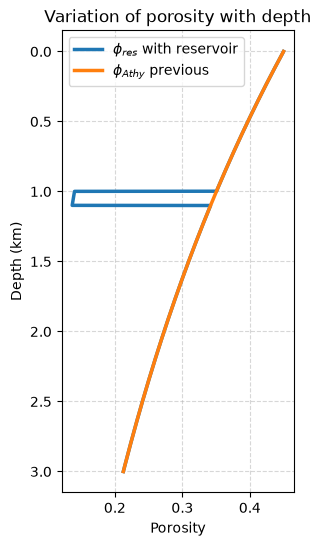

In [54]:
Sw_r = np.ones(npt)

phi_est = (a / (bulk_resistivity * (Sw_r**n) * sigma)) ** (1/m) # depth varying temperature (actual temperature case)
phi_est_cT = (a / (bulk_resistivity * (Sw_r**n) * 2.903916)) ** (1/m) # constant temperature case

plt.figure(figsize=(3,6))
plt.plot(phi_est, dpt, lw = 2.5, label=r"$\phi_{res}$ with reservoir")
plt.plot(phi_sand, dpt, lw = 2.5, label=r"$\phi_{Athy}$ previous")
plt.xlabel("Porosity")
plt.ylabel("Depth (km)")
plt.gca().invert_yaxis()
plt.grid("True", alpha = 0.5, ls = "--")
plt.title("Variation of porosity with depth")
plt.legend()
plt.show()

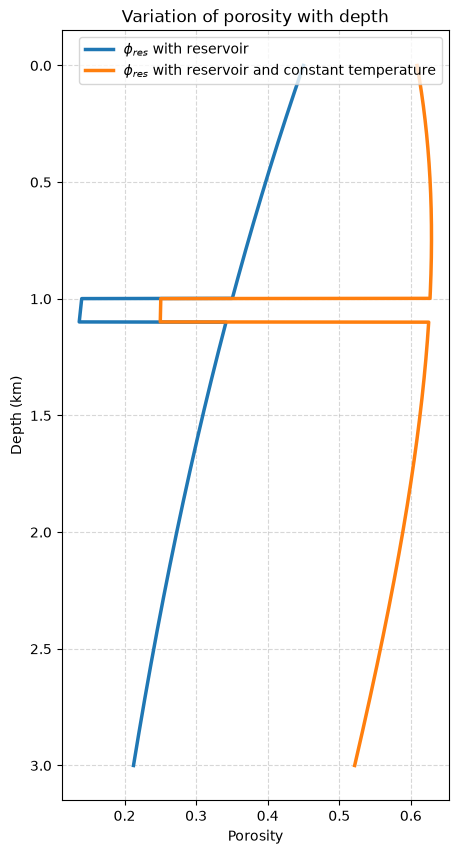

In [56]:
plt.figure(figsize=(5,10))
plt.plot(phi_est, dpt, lw = 2.5, label=r"$\phi_{res}$ with reservoir")
plt.plot(phi_est_cT, dpt, lw = 2.5, label=r"$\phi_{res}$ with reservoir and constant temperature")
plt.xlabel("Porosity")
plt.ylabel("Depth (km)")
plt.gca().invert_yaxis()
plt.grid("True", alpha = 0.5, ls = "--")
plt.title("Variation of porosity with depth")
plt.legend()
plt.show()

Now we do fun stuff

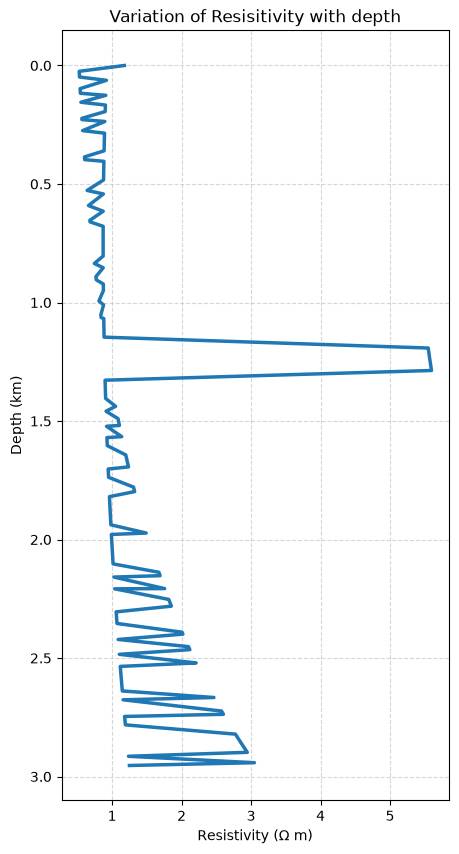

In [51]:
nl = 120 # Sets the total number of layers to 120
rd = np.random.rand(120) # Creates a 120 x 1 columnar array filled with random numbers between 0 and 1
sum_rd = np.sum(rd) # Adds up all the random numbers generated
th_rd = (rd * 3) / sum_rd # Scales those numbers so that total thickness remains 3 km

depth_rd = np.zeros(nl)
phi_rd = np.zeros(nl)

# Initialize first elements 
depth_rd[0] = 0
phi_rd[0] = 0.4

# Loop starts at index 1 
for i in range(1, nl):
    depth_rd[i] = depth_rd[i-1] + th_rd[i-1]
    
    if rd[i] < 0.5:
        phi_rd[i] = 0.6 * np.exp(-0.5 * depth_rd[i])
    else:
        phi_rd[i] = 0.45 * np.exp(-0.25 * depth_rd[i])

temp_grad = 35
temp0 = 25
T_rd = temp0 + temp_grad * depth_rd
sigma_rd = 2.903916 * (1 + 0.0297175 * T_rd + 1.5551 * (10**(-4)) * T_rd**2 - 6.7 * (10**(-7)) * T_rd**3)

# Now we use Archie's equation
a = 1
m = 2
n = 2
Sw_rd = np.ones(len(depth_rd))
Sw_rd[49:52] = 0.4

bulk_resistivity_rd = a / ((phi_rd**m) * (Sw_rd**n) * sigma_rd)

plt.figure(figsize=(5,10))
plt.plot(bulk_resistivity_rd, depth_rd, lw = 2.5)
plt.xlabel(r"Resistivity ($\Omega$ m)")
plt.ylabel("Depth (km)")
plt.gca().invert_yaxis()
plt.grid("True", alpha = 0.5, ls = "--")
plt.title("Variation of Resisitivity with depth")
plt.show()

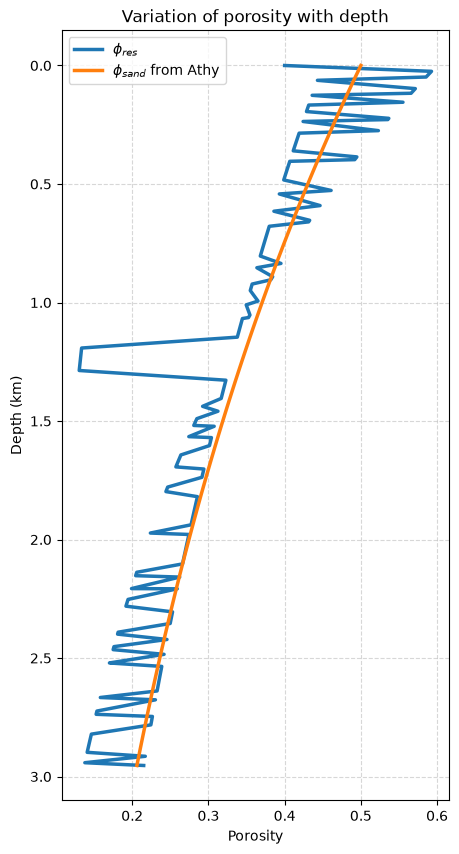

In [61]:
Sw_rd = np.ones(nl)
phi_est_rd = (a / (bulk_resistivity_rd * (Sw_rd**n) * sigma_rd)) ** (1/m)
phi_sand_rd = 0.5 * np.exp(-0.3 * depth_rd)

plt.figure(figsize=(5,10))
plt.plot(phi_est_rd, depth_rd, lw = 2.5, label=r"$\phi_{res}$")
plt.plot(phi_sand_rd, depth_rd, lw = 2.5, label=r"$\phi_{sand}$ from Athy")
plt.xlabel("Porosity")
plt.ylabel("Depth (km)")
plt.gca().invert_yaxis()
plt.grid("True", alpha = 0.5, ls = "--")
plt.title("Variation of porosity with depth")
plt.legend()
plt.show()

Wyllie's Equation

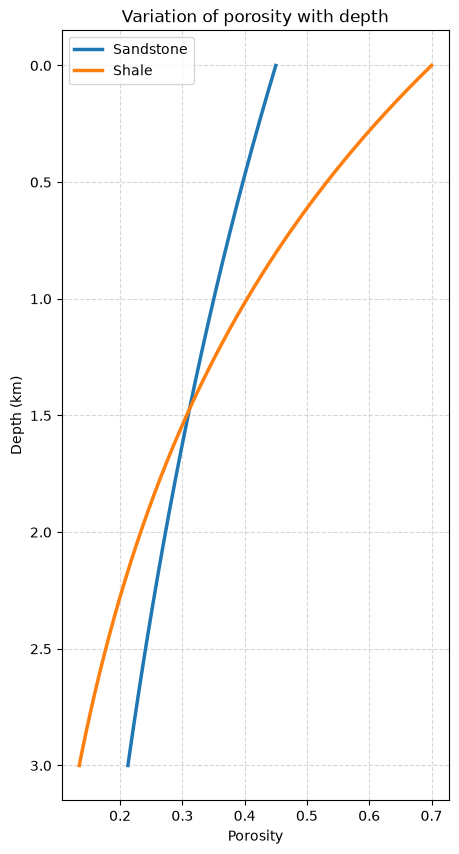

In [62]:
plt.figure(figsize=(5,10))
plt.plot(phi_sand, dpt, lw = 2.5, label = "Sandstone")
plt.plot(phi_mud, dpt, lw = 2.5, label = "Shale")
plt.xlabel("Porosity")
plt.ylabel("Depth (km)")
plt.gca().invert_yaxis()
plt.grid("True", alpha = 0.5, ls = "--")
plt.title("Variation of porosity with depth")
plt.legend()
plt.show()

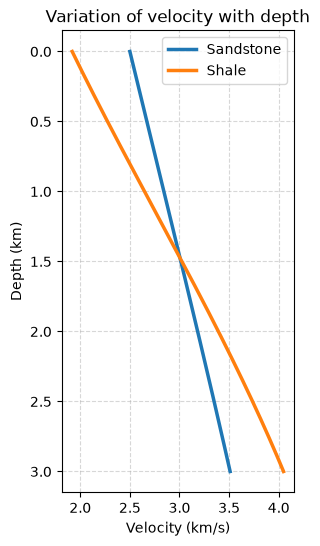

In [63]:
vf = 1.5
vm = 5.5

v = (phi / vf) + ((1 - phi) / vm)
v = 1/v

v_shale = (phi_mud / vf) + ((1 - phi_mud) / vm)
v_shale = 1 / v_shale

plt.figure(figsize=(3,6))
plt.plot(v, dpt, lw = 2.5, label = "Sandstone")
plt.plot(v_shale, dpt, lw = 2.5, label = "Shale")
plt.xlabel("Velocity (km/s)")
plt.ylabel("Depth (km)")
plt.gca().invert_yaxis()
plt.grid("True", alpha = 0.5, ls = "--")
plt.title("Variation of velocity with depth")
plt.legend()
plt.show()